# Part 5 — Iterate $\Phi_\theta$: and does it beat persistence?

> **Extra, read only.** This lecture notebook is kept with its saved outputs. It ran with anemoi-training 0.17 and anemoi-inference 0.12 on the lecture dataset, not with the course kernel, so read it but do not rerun it in class.

**Slides 36–43 · 25 minutes.** Training left an `inference-*.ckpt`: what does it need, what does the runner do at each step, and is the 48 h forecast from **2021-07-01 00:00** better than persistence? Central exercise: RMSE of the course model vs persistence vs Part 1's one-parameter model.

Prerequisites (runbook Phases 1, 4, 6): `data/era5-o48-2020-2021-6h-v1.zarr`, `checkpoints/course-o48-gt128.ckpt`, the course environment (`anemoi-inference` 0.12). One GPU (the acc login nodes have H100s); the whole notebook runs in under a minute.
Tags: `# RUN` = execute now · `# SAVED` = a runbook capture is shown instead · `# REVIEW` = shown in the 30-minute review.

In [1]:
# RUN — paths and environment
import os, re, sys, time, math, subprocess, warnings, logging
from datetime import datetime, timedelta
from pathlib import Path

import numpy as np
import pandas as pd
import xarray as xr
import yaml
import torch
import matplotlib.pyplot as plt
import anemoi.inference

warnings.filterwarnings("ignore")                          # hide library deprecation notices
for name in ("pytorch_lightning", "lightning_fabric", "anemoi"):
    logging.getLogger(name).setLevel(logging.ERROR)        # keep the Python cells quiet; the CLI cell shows its own log

# where things are: <repo>/data/anemoi-course, or the folder named in ANEMOI_COURSE_BASE
BASE = Path(os.environ.get("ANEMOI_COURSE_BASE", "../../../data/anemoi-course")).resolve()
DATA = BASE / "data" / "era5-o48-2020-2021-6h-v1.zarr"    # the course dataset
CK   = BASE / "checkpoints" / "course-o48-gt128.ckpt"     # the inference checkpoint from Part 4
FC   = BASE / "forecast"                                  # where this notebook writes its forecasts
FC.mkdir(exist_ok=True)
CLI  = str(Path(sys.executable).parent / "anemoi-inference")   # the command-line tool of this environment


def cli(*args):
    # run `anemoi-inference <args>`; return its output lines without the "2026-09-17 10:00:00 INFO " prefix
    result = subprocess.run([CLI, *args], stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True, cwd=BASE)
    lines = []
    for line in result.stdout.splitlines():
        if line.strip():
            lines.append(re.sub(r"^\S+ \S+ (INFO|WARNING) ", "", line))
    return lines


print("anemoi-inference", anemoi.inference.__version__, "| torch", torch.__version__)
print("dataset exists:", DATA.exists(), "| checkpoint exists:", CK.exists())

anemoi-inference 0.12.0 | torch 2.10.0+cu128
dataset exists: True | checkpoint exists: True


## 1 · The checkpoint: $\theta$ plus everything the loop needs (slides 37, 38)

`inspect`, `validate` and `Checkpoint(path)` read the metadata record without loading the weights: variables by category, grid, `timestep`, `multi_step_input`, the recorded dataloader splits.

> **Predict first:** how many variables, and how many of them prognostic / forcing / diagnostic? For `date: 2021-07-01T00`, which two dates must the input hold?

In [2]:
# REVIEW — what the checkpoint knows: variables by category (CLI), then dates, grid and splits (Python)
from anemoi.inference.checkpoint import Checkpoint

# 1) the CLI lists every variable as "name => category, category, ..."
categories = {}
for line in cli("inspect", "--variables", str(CK)):
    if "=>" in line:
        name, cats = line.split("=>")
        categories[name.strip()] = cats


def count(word):
    # how many variables carry `word` in their category list
    return sum(word in cats for cats in categories.values())


print(len(categories), "variables:", count("prognostic"), "prognostic |", count("forcing"), "forcing, of which",
      count("computed"), "computed by the runner |", count("diagnostic"), "diagnostic")
print("validate:", cli("validate", str(CK))[-1])                     # last line: "Environment validation passed"
print("pinned versions:", [l for l in cli("inspect", "--requirements", str(CK)) if l.startswith(("anemoi-models", "anemoi-graphs"))])

# 2) the same record from Python
ck = Checkpoint(str(CK))
meta = ck.multi_dataset_metadata["data"]                              # the per-dataset part of the record
date = datetime(2021, 7, 1, 0)
input_dates = [str(date + lag) for lag in ck.lagged]                  # ck.lagged = [-6 h, 0 h] because multi_step_input = 2
print("\ntimestep", ck.timestep, "| multi_step_input", ck.multi_step_input, "| input dates for", date, ":", input_dates)
print("grid", meta.grid, "| grid points", meta.number_of_grid_points, "| input features", meta.number_of_input_features)
print("computed by the runner:", meta.model_computed_variables)
for split in ("training", "validation", "test"):                      # what `input: test` would open
    args = meta.open_dataset_args_kwargs(use_original_paths=False, from_dataloader=split)[1]
    print(f"input: {split:10s} -> open_dataset(**{args})")
print("48 h =", math.ceil(timedelta(hours=48) / ck.rollout_shift), "model calls")

43 variables: 28 prognostic | 13 forcing, of which 9 computed by the runner | 2 diagnostic


validate: Environment validation passed


pinned versions: ['anemoi-graphs==0.9.7', 'anemoi-models==0.19.0']

timestep 6:00:00 | multi_step_input 2 | input dates for 2021-07-01 00:00:00 : ['2021-06-30 18:00:00', '2021-07-01 00:00:00']
grid O48 | grid points 10944 | input features 41
computed by the runner: ('cos_julian_day', 'cos_latitude', 'cos_local_time', 'cos_longitude', 'insolation', 'sin_julian_day', 'sin_latitude', 'sin_local_time', 'sin_longitude')
input: training   -> open_dataset(**{'dataset': 'era5-o48-2020-2021-6h-v1', 'frequency': '6h', 'end': 2020})
input: validation -> open_dataset(**{'dataset': 'era5-o48-2020-2021-6h-v1', 'frequency': '6h', 'start': '2021-01', 'end': '2021-06'})
input: test       -> open_dataset(**{'dataset': 'era5-o48-2020-2021-6h-v1', 'frequency': '6h', 'start': '2021-07'})
48 h = 8 model calls


**Expected:** 43 variables = **28 prognostic + 13 forcing** (9 computed: `insolation`, day/time and lat/lon terms) **+ 2 diagnostic** (`cp`, `tp`); `validate` passes; `anemoi-models==0.19.0`.
`timestep 6:00:00`, `multi_step_input 2` → the input must hold **2021-06-30 18:00 and 2021-07-01 00:00**; 10,944 points on `O48`, 41 input features; 8 calls for 48 h, 12 for 72 h.
The `test` split is recorded as `start: 2021-07` on the dataset *name* — both facts bite in section 3.

## 2 · The inference configuration (slide 40)

One flat YAML validated by a pydantic model with `extra="forbid"`; only `checkpoint` is required. Not the Hydra tree of Part 3: no `defaults`, overrides are `key=value` on the command line.

In [3]:
# RUN — write inference_part5.yaml, check it against the schema, then try a misspelt key
from pydantic import ValidationError
from anemoi.inference.config.run import RunConfiguration

INF = BASE / "config" / "inference_part5.yaml"
INF.write_text(f'''checkpoint: {CK}
date: 2021-07-01T00
lead_time: 48
input: {{dataset: {DATA}}}
output:
  tee:
    - printer
    - netcdf: {{path: {FC}/part5_forecast_2021070100.nc, post_processors: [accumulate_from_start_of_forecast]}}
    - truth: {{output: {{netcdf: {{path: {FC}/part5_truth_2021070100.nc}}}}}}
write_initial_state: true
''')
print(INF.read_text())

raw = yaml.safe_load(INF.read_text())        # the file as a Python dict
cfg = RunConfiguration(**raw)                # the schema fills in every key we did not write
for key in ("device", "precision", "output_frequency", "initial_state_categories"):
    print(f"default {key:25s} = {getattr(cfg, key)}")
print("lead_time if omitted =", RunConfiguration.model_fields["lead_time"].default)

try:
    RunConfiguration(**raw, lead_tim=48)     # a typo: the schema refuses unknown keys
except ValidationError as e:
    print("\nmisspelt key ->", e.errors()[0]["loc"], e.errors()[0]["msg"])

checkpoint: /gpfs/scratch/bsc32/bsc437208/anemoi-course/checkpoints/course-o48-gt128.ckpt
date: 2021-07-01T00
lead_time: 48
input: {dataset: /gpfs/scratch/bsc32/bsc437208/anemoi-course/data/era5-o48-2020-2021-6h-v1.zarr}
output:
  tee:
    - printer
    - netcdf: {path: /gpfs/scratch/bsc32/bsc437208/anemoi-course/forecast/part5_forecast_2021070100.nc, post_processors: [accumulate_from_start_of_forecast]}
    - truth: {output: {netcdf: {path: /gpfs/scratch/bsc32/bsc437208/anemoi-course/forecast/part5_truth_2021070100.nc}}}
write_initial_state: true

default device                    = None
default precision                 = None
default output_frequency          = None
default initial_state_categories  = ['prognostics', 'constant_forcings']
lead_time if omitted = 10d

misspelt key -> ('lead_tim',) Extra inputs are not permitted


**Expected:** slide 40's file with `input: {dataset: <path>}` instead of `input: test` (section 3 says why). Defaults: `device None` (auto), `precision None` (from the checkpoint),
`initial_state_categories ['prognostics', 'constant_forcings']`, `lead_time` would be `10d`. The misspelt `lead_tim` is refused: `Extra inputs are not permitted`.

## 3 · The loop by hand (slides 36, 38, 39)

`Runner.run(input_states=…, lead_time=…)` is a generator: one state per model call. We build the input state ourselves from the runner's input objects (the contract of slide 38), then watch what each yielded state holds (slide 39).

In [4]:
# REVIEW — the loop by hand: build the input state, then call the model eight times on the GPU
from anemoi.inference.runners.default import DefaultRunner

config = RunConfiguration(checkpoint=str(CK), date="2021-07-01T00", lead_time=48, input={"dataset": str(DATA)}, device="cuda", verbosity=0)
runner = DefaultRunner(config)

# the input state = the 28 prognostic variables at the two lagged dates + the 4 constant forcings read from the dataset
state = runner.prognostics_inputs["data"].create_input_state(date=config.date)
constants = runner.constant_forcings_inputs["data"].create_input_state(date=config.date)
state["fields"].update(constants["fields"])
print("input state:", len(state["fields"]), "fields | shape of 2t:", state["fields"]["2t"].shape, "= (multistep_input, grid points) | date", state["date"])

prognostic = set(meta.prognostic_variables)
diagnostic = set(meta.diagnostic_variables)
manual_2t = {}                                             # 2t of every output state; section 5 compares it with the CLI file
start = time.time()
for call, output in enumerate(runner.run(input_states={"data": state}, lead_time=48), start=1):
    out = output["data"]                                   # one state per call: date, step, fields
    fields = out["fields"]
    manual_2t[out["date"]] = fields["2t"].copy()
    fed_back = len(prognostic & set(fields))               # prognostics become the next input
    written_only = sorted(diagnostic & set(fields))        # diagnostics (cp, tp) are written, never fed back
    print(f"call {call}  {out['date']}  step {str(out['step']):>15s}  fields {len(fields)}: fed back {fed_back}, written only {written_only}"
          f"  2t {fields['2t'].min():.0f}..{fields['2t'].max():.0f} K  {time.time() - start:4.1f} s")

input state: 32 fields | shape of 2t: (2, 10944) = (multistep_input, grid points) | date 2021-07-01 00:00:00


call 1  2021-07-01 06:00:00  step         6:00:00  fields 30: fed back 28, written only ['cp', 'tp']  2t 202..312 K  22.5 s
call 2  2021-07-01 12:00:00  step        12:00:00  fields 30: fed back 28, written only ['cp', 'tp']  2t 202..315 K  22.5 s
call 3  2021-07-01 18:00:00  step        18:00:00  fields 30: fed back 28, written only ['cp', 'tp']  2t 201..315 K  22.5 s
call 4  2021-07-02 00:00:00  step  1 day, 0:00:00  fields 30: fed back 28, written only ['cp', 'tp']  2t 200..314 K  22.6 s
call 5  2021-07-02 06:00:00  step  1 day, 6:00:00  fields 30: fed back 28, written only ['cp', 'tp']  2t 199..317 K  22.6 s
call 6  2021-07-02 12:00:00  step 1 day, 12:00:00  fields 30: fed back 28, written only ['cp', 'tp']  2t 199..318 K  22.6 s
call 7  2021-07-02 18:00:00  step 1 day, 18:00:00  fields 30: fed back 28, written only ['cp', 'tp']  2t 198..324 K  22.7 s


call 8  2021-07-03 00:00:00  step 2 days, 0:00:00  fields 30: fed back 28, written only ['cp', 'tp']  2t 198..329 K  22.7 s


**Expected:** the input state holds **32 fields of shape `(2, 10944)`** (28 prognostics + 4 constant forcings; the 9 computed forcings are added by the runner when it builds the `(2, 41, 10944)` tensor).
Eight output states, 2021-07-01 06:00 → 2021-07-03 00:00, **30 fields each**: 28 fed back, `cp`, `tp` written only. First call ≈ 4 s (it loads the model), then ≈ 0.2–0.3 s per call.
`input: test` fails for this date: the split starts at 2021-07-01T00 and `multistep_input = 2` needs 06-30 18:00 — see change.md, slide 38.

## 4 · Running: the CLI (slide 41)

`anemoi-inference run inference_part5.yaml` does what section 3 did, plus the outputs (`printer`, `netcdf`, `truth`). `device` is auto-detected: the GPU of this node; on a compute node the same command goes through `srun --gres=gpu:1`.

In [5]:
# RUN — the same 48 h through the command line: the log, the printer blocks, the files
for old in (FC / "part5_forecast_2021070100.nc", FC / "part5_truth_2021070100.nc"):
    old.unlink(missing_ok=True)                            # start clean

start = time.time()
log = cli("run", str(INF))                                 # device is auto-detected: the GPU of this node
wall = time.time() - start
(FC / "part5_run.log").write_text("\n".join(log))

block_lines = [i for i, line in enumerate(log) if "latitudes=(" in line]    # `printer` writes one header per valid time
print(f"$ anemoi-inference run {INF.name}  ->  {wall:.0f} s wall, {len(block_lines)} printer blocks\n")

for line in log:                                           # the four log lines worth reading
    if re.search(r"Using \w+Runner|Preparing input tensor|Loading Checkpoint|Forecasting \(", line):
        print(line[:120])

print("\nprinter blocks (date, fields):")
for i in block_lines:
    print(log[i][:120])

print("\nstep-0 block in full:")
print("\n".join(log[block_lines[0]:block_lines[1]]))

for f in sorted(FC.glob("part5_*.nc")):
    print(f"{f.name:32s} {f.stat().st_size / 1e6:5.1f} MB")

$ anemoi-inference run inference_part5.yaml  ->  21 s wall, 9 printer blocks

Using DefaultRunner runner, device=cuda
Preparing input tensor with shape (2, 41, 10944)
Loading Checkpoint(/gpfs/scratch/bsc32/bsc437208/anemoi-course/checkpoints/course-o48-gt128.ckpt): 3 seconds.
Forecasting (2021-07-01 06:00:00): 0.9 seconds.
Forecasting (2021-07-01 12:00:00): 32.8 milliseconds.
Forecasting (2021-07-01 18:00:00): 24.8 milliseconds.
Forecasting (2021-07-02 00:00:00): 28.4 milliseconds.
Forecasting (2021-07-02 06:00:00): 29.1 milliseconds.
Forecasting (2021-07-02 12:00:00): 28.1 milliseconds.
Forecasting (2021-07-02 18:00:00): 24.8 milliseconds.
Forecasting (2021-07-03 00:00:00): 26.8 milliseconds.

printer blocks (date, fields):
[data] 😀 date=2021-07-01T00:00:00 latitudes=(10944,) longitudes=(10944,) fields=32
[data] 😀 date=2021-07-01T06:00:00 latitudes=(10944,) longitudes=(10944,) fields=30
[data] 😀 date=2021-07-01T12:00:00 latitudes=(10944,) longitudes=(10944,) fields=30
[data] 😀 date=20

**Expected:** nine printer blocks, `2021-07-01T00` (step 0, `write_initial_state: true`) to `2021-07-03T00`, `latitudes=(10944,)`. The field count is **not** constant: step 0 has `fields=32`
(28 prognostics + 4 constant forcings), steps 1–8 have `fields=30` (28 + `cp`, `tp`). `Preparing input tensor with shape (2, 41, 10944)`; the checkpoint loads in ≈ 2 s, the eight calls take well under a second on the GPU, about 10 s wall including start-up. Two files of 12 MB.

## 5 · The output file, and two maps (slide 42)

One array per field, `(time, values)`, coordinates `time`, `latitude`, `longitude`, `forecast_period`, `forecast_reference_time`; no lat × lon reconstruction. Then `2t` at +6 h and +48 h against the truth.

In [6]:
# REVIEW — open the two files with xarray and run slide 42's checks
fc = xr.open_dataset(FC / "part5_forecast_2021070100.nc")      # the forecast
tr = xr.open_dataset(FC / "part5_truth_2021070100.nc")         # the analysis at the same times, taken from the dataset

print("times:", len(fc.time), "from", str(fc.time.values[0])[:13], "to", str(fc.time.values[-1])[:13])
print("coordinates:", list(fc.coords))

variables = set(fc.data_vars)
others = sorted(variables - prognostic - diagnostic)
print("variables:", len(variables), "= prognostic", len(variables & prognostic), "+ diagnostic", len(variables & diagnostic), "+ other", others)
print("shape of 2t:", fc["2t"].shape, "= (time, grid points)")

for v in ("2t", "tp", "z"):                                     # NaN count per time step
    nans = np.isnan(fc[v].values).sum(axis=1)
    print(f"NaNs per step in {v:2s}:", [int(n) for n in nans])

tp = fc["tp"].values[1:]                                        # accumulated precipitation, steps 1..8 (step 0 is NaN)
print("tp non-decreasing from step 1:", bool((np.diff(tp, axis=0) >= 0).all()), f"| global mean at +48 h: {1000 * tp[-1].mean():.2f} mm")
print("truth file:", len(tr.data_vars), "variables | tp in truth:", "tp" in tr, "| same times as the forecast:", bool((fc.time.values == tr.time.values).all()))

differences = []                                                # the manual loop of section 3 and the CLI file must agree
for date, manual in manual_2t.items():
    from_file = fc["2t"].sel(time=np.datetime64(date)).values
    differences.append(round(float(np.abs(from_file - manual).max()), 3))
print("max |manual loop − CLI| for 2t per step [K]:", differences)

times: 9 from 2021-07-01T00 to 2021-07-03T00
coordinates: ['forecast_reference_time', 'time', 'forecast_period', 'latitude', 'longitude']
variables: 34 = prognostic 28 + diagnostic 2 + other ['lsm', 'sdor', 'slor', 'z']
shape of 2t: (9, 10944) = (time, grid points)
NaNs per step in 2t: [0, 0, 0, 0, 0, 0, 0, 0, 0]
NaNs per step in tp: [10944, 0, 0, 0, 0, 0, 0, 0, 0]
NaNs per step in z : [0, 10944, 10944, 10944, 10944, 10944, 10944, 10944, 10944]
tp non-decreasing from step 1: True | global mean at +48 h: 0.69 mm
truth file: 32 variables | tp in truth: False | same times as the forecast: True


max |manual loop − CLI| for 2t per step [K]: [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]


**Expected:** 9 times; **34 data variables, not 30**: 28 + 2 plus `lsm`, `sdor`, `slor`, `z` written at step 0 only (NaN after); `tp`, `cp` NaN at step 0 only; `tp` non-decreasing, ≈ 0.7 mm global mean at +48 h. The truth file has 32 variables and no `tp`. Manual loop and CLI file agree to 0.0 K.

+ 6 h  std of the 6-h change of 2t: forecast 1.75 K, truth 2.80 K  | std of the field: forecast 15.3 K, truth 15.5 K
+48 h  std of the 6-h change of 2t: forecast 2.05 K, truth 2.61 K  | std of the field: forecast 17.5 K, truth 15.2 K


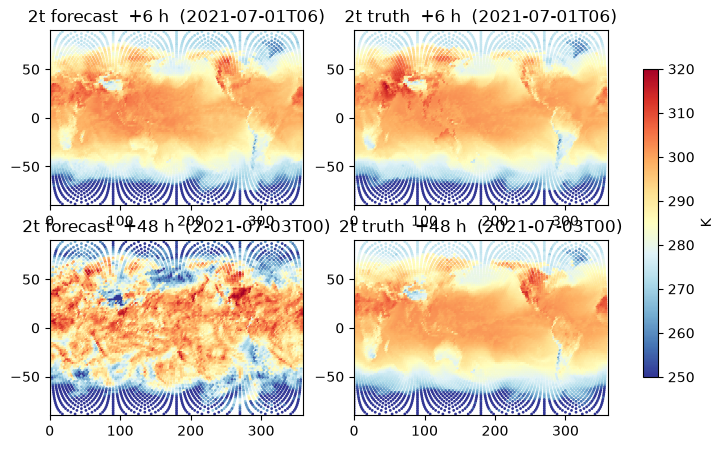

In [7]:
# RUN — 2t maps at +6 h and +48 h, forecast against truth, and one number for the smoothing
lat = fc["latitude"].values
lon = fc["longitude"].values

for k in (1, 8):                                                 # k = time index, lead = 6 k hours
    change_fc = fc["2t"].values[k] - fc["2t"].values[k - 1]      # the 6-hourly change of the forecast
    change_tr = tr["2t"].values[k] - tr["2t"].values[k - 1]      # and of the truth
    print(f"+{6 * k:2d} h  std of the 6-h change of 2t: forecast {change_fc.std():.2f} K, truth {change_tr.std():.2f} K"
          f"  | std of the field: forecast {fc['2t'].values[k].std():.1f} K, truth {tr['2t'].values[k].std():.1f} K")

fig, ax = plt.subplots(2, 2, figsize=(9, 5))
for row, k in enumerate([1, 8]):
    for col, (name, ds) in enumerate([("forecast", fc), ("truth", tr)]):
        sc = ax[row, col].scatter(lon, lat, c=ds["2t"].values[k], s=1, cmap="RdYlBu_r", vmin=250, vmax=320)   # one dot per grid point
        ax[row, col].set_title(f"2t {name}  +{6 * k} h  ({str(ds.time.values[k])[:13]})")
        ax[row, col].set_xlim(0, 360)
        ax[row, col].set_ylim(-90, 90)
fig.colorbar(sc, ax=ax, label="K", shrink=0.8)
fig.savefig("part5-2t-maps.png", dpi=80, bbox_inches="tight")
plt.show()

**Expected:** 9 times; **34 data variables, not 30**: 28 + 2 plus `lsm`, `sdor`, `slor`, `z` written at step 0 only (NaN after); `tp`, `cp` NaN at step 0 only; `tp` non-decreasing, ≈ 0.7 mm global mean at +48 h.
The truth file has 32 variables (no `tp`: it cannot be verified this way). Manual loop and CLI agree to 0.0 K. The 6-h *change* is damped (1.75 vs 2.80 K at +6 h) but the field is not smoother
at +48 h (17.5 vs 15.2 K): at +6 h the maps are alike; at +48 h the forecast is blotchy — an under-trained model lets its own errors grow before the MSE smoothing sets in.

## 6 · Central exercise: RMSE against truth and persistence (slide 43)

$\mathrm{RMSE}_v(s) = \sqrt{\sum_i a_i (\hat x_{i,v,s} - x_{i,v,s})^2}$ with Part 1's area weights $a_i$; persistence is $\hat x_s = x_0$; for `2t` the third line is Part 1's $\hat X_{t+\Delta t} = X_t + \theta (X_t - X_{t-\Delta t})$, refitted on 2020.

> **Predict first:** at which lead does the course model stop beating persistence for `2t`? Does it beat persistence at +6 h for every variable?

**Expected:** `2t` beats persistence at **+6 h (2.45 vs 2.89 K)** and +12 h (3.51 vs 4.22), loses from +18 h (3.79 vs 3.16) to +48 h (9.63 vs 2.65); `msl`, `z_500` win to +24 h, `t_850` to +30 h, **`10u` never** (2.31 vs 2.20 m/s at +6 h).
The one-parameter model gets $\theta \approx -0.09$ and stays within 0.15 K of persistence. Same values as `results/06-rmse.csv` (the runbook's CPU run: GPU and CPU agree to two decimals). Verdict: a real correction at +6/+12 h, and errors that compound from +18 h — the reason rollout training exists (Part 6).

In [8]:
# REVIEW — RMSE per variable and lead time: the forecast against persistence
# area weight of a grid point = area of its latitude band / number of points in that band (the same weights as Part 1)
row_lat, row_n = np.unique(lat, return_counts=True)                     # the 96 latitude rows of the O48 grid
edges = np.concatenate([[-90.0], (row_lat[:-1] + row_lat[1:]) / 2, [90.0]])
band_area = np.diff(np.sin(np.deg2rad(edges)))                          # area of each band on the unit sphere (up to a constant)
area = (band_area / row_n)[np.searchsorted(row_lat, lat)]               # one weight per point
area = area / area.sum()                                                # weights sum to 1


def rmse(x, y):
    # area-weighted root-mean-square difference of two fields
    return float(np.sqrt(np.sum(area * (x - y) ** 2)))


VARS = ["2t", "msl", "z_500", "t_850", "10u"]                           # tp is not in the truth file
rows = []
for v in VARS:
    for k in range(1, 9):                                                # k = time index, lead = 6 k hours
        forecast_err = rmse(fc[v].values[k], tr[v].values[k])
        persistence_err = rmse(tr[v].values[0], tr[v].values[k])        # persistence = the analysis at t0, unchanged
        rows.append((v, 6 * k, forecast_err, persistence_err))
df = pd.DataFrame(rows, columns=["variable", "lead_h", "rmse_forecast", "rmse_persistence"])
df["beats_persistence"] = df.rmse_forecast < df.rmse_persistence
df.to_csv("part5-rmse.csv", index=False)

print(df[df.variable == "2t"].to_string(index=False))
print("\nlast lead at which the forecast beats persistence:", df[df.beats_persistence].groupby("variable").lead_h.max().to_dict())
print("never beats persistence:", sorted(set(VARS) - set(df[df.beats_persistence].variable)))

variable  lead_h  rmse_forecast  rmse_persistence  beats_persistence
      2t       6       2.450399          2.886288               True
      2t      12       3.505237          4.215160               True
      2t      18       3.791073          3.162149              False
      2t      24       4.373559          2.101010              False
      2t      30       5.759710          3.425665              False
      2t      36       7.095033          4.633496              False
      2t      42       8.332963          3.746059              False
      2t      48       9.634113          2.647747              False

last lead at which the forecast beats persistence: {'2t': 12, 'msl': 24, 't_850': 30, 'z_500': 24}
never beats persistence: ['10u']


**Expected:** for `2t`: 2.45 vs 2.89 K at +6 h (forecast better), 3.79 vs 3.16 K at +18 h (persistence better), 9.63 vs 2.65 K at +48 h. `10u` never beats persistence.

In [9]:
# REVIEW — Part 1's one-parameter model on the same two input states, and the full table
from anemoi.datasets import open_dataset

# X(t+6h) = X(t) + theta * (X(t) - X(t-6h)); theta fitted on 2020 by least squares, as in Part 1
X = np.asarray(open_dataset(DATA, select=["2t"], start=2020, end=2020)[:])[:, 0, 0, :]    # (1464 dates, 10944 points)
d_prev = X[1:-1] - X[:-2]                                # the change we know
d_next = X[2:] - X[1:-1]                                 # the change we want
theta = float((area * d_prev * d_next).sum() / (area * d_prev * d_prev).sum())

prev, cur = state["fields"]["2t"][0], state["fields"]["2t"][1]     # the two input states of section 3
one_param = []
for k in range(1, 9):
    prev, cur = cur, cur + theta * (cur - prev)          # one step of the one-parameter model
    one_param.append(rmse(cur, tr["2t"].values[k]))

table = {}                                               # one column per variable: "forecast / persistence  yes|no"
for v in VARS:
    g = df[df.variable == v]
    table[v] = [f"{f:8.2f} / {p:7.2f} {'yes' if b else 'no '}" for f, p, b in zip(g.rmse_forecast, g.rmse_persistence, g.beats_persistence)]
table = pd.DataFrame(table, index=[f"+{h} h" for h in range(6, 49, 6)])
table[f"2t one-parameter (theta = {theta:+.3f})"] = np.round(one_param, 2)
print(table.to_string())
print("units: 2t, t_850 K · msl Pa · z_500 m²/s² · 10u m/s")

                           2t                     msl                   z_500                   t_850                     10u  2t one-parameter (theta = -0.085)
+6 h       2.45 /    2.89 yes    191.58 /  240.90 yes    212.77 /  237.93 yes      1.28 /    1.42 yes      2.31 /    2.20 no                                2.89
+12 h      3.51 /    4.22 yes    319.14 /  374.75 yes    362.87 /  405.84 yes      2.04 /    2.34 yes      3.31 /    3.11 no                                4.11
+18 h      3.79 /    3.16 no     437.07 /  488.68 yes    499.45 /  556.02 yes      2.52 /    2.77 yes      3.91 /    3.62 no                                3.02
+24 h      4.37 /    2.10 no     549.21 /  572.25 yes    631.14 /  664.13 yes      2.94 /    3.09 yes      4.33 /    3.96 no                                2.10
+30 h      5.76 /    3.43 no     655.56 /  655.32 no     769.26 /  745.81 no       3.35 /    3.44 yes      4.80 /    4.28 no                                3.41
+36 h      7.10 /    4.63 no     7

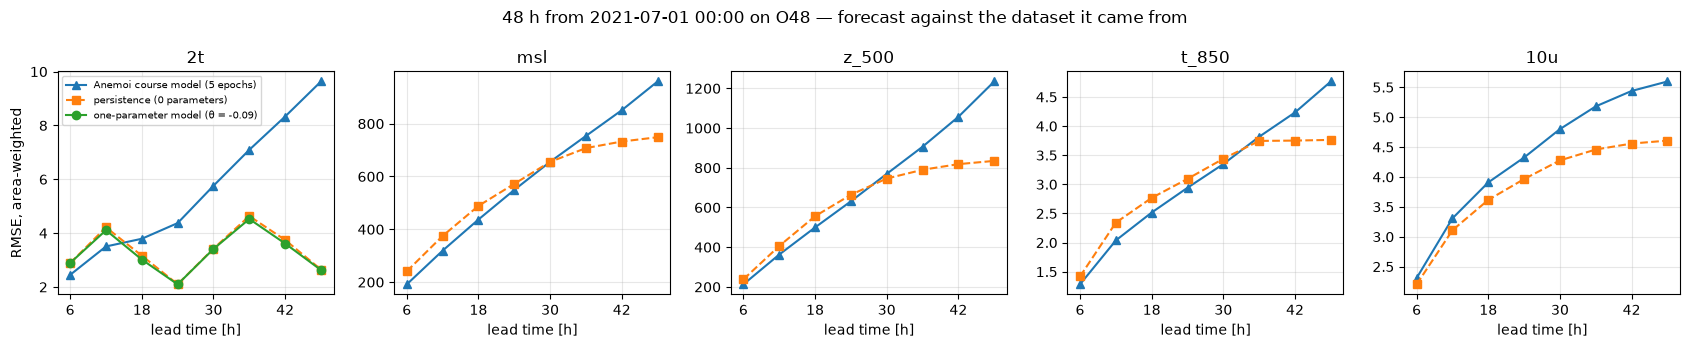

In [10]:
# REVIEW — the plot of slide 43: forecast vs persistence per variable, plus the one-parameter line for 2t
fig, axes = plt.subplots(1, len(VARS), figsize=(3.4 * len(VARS), 3.5))
for ax_, v in zip(axes, VARS):
    g = df[df.variable == v]
    ax_.plot(g.lead_h, g.rmse_forecast, "^-", label="Anemoi course model (5 epochs)")
    ax_.plot(g.lead_h, g.rmse_persistence, "s--", label="persistence (0 parameters)")
    if v == "2t":
        ax_.plot(g.lead_h, one_param, "o-", label=f"one-parameter model (θ = {theta:+.2f})")
    ax_.set_title(v)
    ax_.set_xlabel("lead time [h]")
    ax_.set_xticks(range(6, 49, 12))
    ax_.grid(alpha=.3)
axes[0].set_ylabel("RMSE, area-weighted")
axes[0].legend(fontsize=7)
fig.suptitle("48 h from 2021-07-01 00:00 on O48 — forecast against the dataset it came from")
fig.tight_layout()
fig.savefig("part5-rmse.png", dpi=100)
plt.show()

**Expected:** five panels; the forecast line starts below persistence and crosses it at +18 h (`2t`), around +30 h (`msl`, `z_500`, `t_850`), and never starts below it (`10u`); the one-parameter line hugs persistence.

## 7 · Regional models and coupling (slide 43) `# SAVED`

No limited-area checkpoint in the course: the `input: cutout` and `runner: external-graph` YAMLs are shown on slide 43 and validated in change.md (slide 43, finding 4), not run here.

> **Checkpoint:** only the analysis at $t_0$ is available and `multistep_input` is 2 — what happens? *Input creation fails before any model call (section 3): the earlier analysis is required, the lead time is not involved.*

> **Checkpoint (central exercise):** did the course model beat persistence? *`2t`: yes at +6 h and +12 h, no from +18 h; `10u`: never. Quote the two `2t` numbers at +6 h and +48 h, and name the Part 6 change you would try first.*